In [1]:
import os, sys

# Make sure we're in the project root
os.chdir("/Users/danesh/Documents/GitHub/trueQ")

# Ensure project root is on sys.path
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from config import *
from noise_models import *

In [2]:
import trueq as tq
from trueq import Gate
import random
import numpy as np
import trueq.simulation as tqs

In [3]:
def random_tuple(n_qubits):

    # Generate a list of numbers from 0 to n
    numbers = list(range(n_qubits))
    
    # Shuffle the list to randomize the selection
    random.shuffle(numbers)
    
    # Determine the number of pairs (n//2 - 1)
    num_pairs = n_qubits // 2 
    
    # Create the required number of tuples
    tuple_list = [tuple(numbers[2 * i: 2 * i + 2]) for i in range(num_pairs)]
    
    # Find the remaining numbers that are not used in the tuples
    used_numbers = set(num for t in tuple_list for num in t)
    missing_numbers = list(set(range(n_qubits)) - used_numbers)

    return tuple_list, missing_numbers



def easy_cycle_NISQ(n_qubits):

    easy_gate_cycle = {}

    for i in range(n_qubits):
        easy_gate_cycle[i] = Gate.random(2)
    
    return tq.Cycle(easy_gate_cycle)


def hard_cycle_NISQ(n_qubits):

    hard_gate_cycle = {}
    list_tuples, missing_num = random_tuple(n_qubits)
    
    # 50/50 chance to remove one tuple
    if random.random() < 0.5 and list_tuples:
        list_tuples.pop(random.randint(0, len(list_tuples) - 1))

    for i in range(len(list_tuples)):
        hard_gate_cycle[list_tuples[i]] = Gate.cx


    return tq.Cycle(hard_gate_cycle, marker= 2)


def random_circuit_NISQ(n_qubits, n_hard_cycles):

    circ_lst = []

    for i in range(n_hard_cycles):

        circ_lst.append(easy_cycle_NISQ(n_qubits))
        circ_lst.append(hard_cycle_NISQ(n_qubits))
    
    circ_lst.append(easy_cycle_NISQ(n_qubits))

    final_circuit = tq.Circuit(circ_lst)
    final_circuit.measure_all()

    return final_circuit

In [4]:
random_circuit_NISQ(4,5).draw()

DisplayWrapper(<svg xmlns="http://w...)

In [5]:
cnot_gate_rotation = 0.073675/2
x_strength = 0.000

sim = tq.Simulator()
        
noisy_sim = (
    sim.add_overrotation(single_sys=x_strength, match=tqs.GateMatch(tq.Gate.sx))
        .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=tqs.GateMatch(tq.Gate.cx))
)

In [6]:
cnot_fid= 0.9979913354320316
i_fid = 1

hard_fids = {Gate.cx: cnot_fid}

In [7]:
def get_hard_cycles(circuit: tq.Circuit):

    return [circuit[2*k+1] for k in range(circuit.n_cycles//2 -1)]


In [8]:
def cycle_fid(cycle):
    fid = 1
    for gate in cycle.gates.values():
        fid *= hard_fids[gate]
    ### for 4 qubit circuits
    if len(list(cycle.gates.keys())) == 1:
        fid *= i_fid**2
    return fid

def f_cb(circuit):
    fid = i_fid**circuit.n_meas
    for hard_cycle in get_hard_cycles(circuit):
        fid *= cycle_fid(hard_cycle)
    return fid

In [9]:
def cycle_fid(cycle):
    fid = 1
    for gate in cycle.gates.values():
        fid *= hard_fids[gate]
    ### for 4 qubit circuits
    if len(list(cycle.gates.keys())) == 1:
        fid *= i_fid**2
    return fid

In [10]:
import trueq.math as tqm

ideal_sim = tq.Simulator()

def f_rc(circuit: tq.Circuit, noisy_sim, n_randomizations=200):

    rc_circuits = tq.randomly_compile(circuit, n_compilations=n_randomizations) ## Generates RC circuits
    compiled_circs = transpiler.compile(rc_circuits)
    ideal_unitary_matrix = tq.Simulator().operator(circuit=circuit).mat() ## Ideal Circuit Unitary Matrix Representation
    ideal_unitary_matrix_superop = tqm.Superop.from_unitary(ideal_unitary_matrix) ## Converting Ideal Unitary to Superoperator
    noisy_unitaries_rc = [noisy_sim.operator(circuit= rc_cir).mat() for rc_cir in compiled_circs] ## Getting the noisy unitary matrix representation of each RC circuit
    noisy_unitaries_superops = [tqm.Superop.from_unitary(noisy_unitary) for noisy_unitary in noisy_unitaries_rc] ## Converting RC to Superoperators
    fidelities = [(noisy_unitary@ideal_unitary_matrix_superop.adj).fidelity for noisy_unitary in noisy_unitaries_superops] ## Calculating the fidelity of the RC circuits with respect to the ideal target

    return np.mean(fidelities) ## Returning the mean fidelity of the RC circuits

In [11]:
c = random_circuit_NISQ(4,5)
c.draw()

DisplayWrapper(<svg xmlns="http://w...)

In [12]:
ZXZXZ_decompose(c).draw()

DisplayWrapper(<svg xmlns="http://w...)

In [13]:
tq.Gate(noisy_sim.operator(circuit=c).mat()).is_unitary

True

In [14]:
import pandas as pd
import time

# Parameters
n_qubits = 4
depths = [5, 10, 15, 20]
circuits_per_depth = 20
n_compilations = 200  # Number of random compilations for f_rc

# Create data table
data = []

print("Generating circuits and computing fidelities...")
print("This may take several minutes...")

for depth in depths:
    print(f"\nProcessing depth {depth}...")
    
    for circuit_idx in range(circuits_per_depth):
        print(f"  Circuit {circuit_idx + 1}/20", end="\r")
        
        # Generate random circuit
        circuit = random_circuit_NISQ(n_qubits, depth)
        
        # Compute f_cb (analytical estimate)
        f_cb_value = f_cb(circuit)
        
        # Compute f_rc (randomized compiling estimate)
        f_rc_value = f_rc(circuit, noisy_sim, n_compilations)
        
        # Store data
        data.append({
            'Circuit_ID': f"D{depth}_C{circuit_idx+1}",
            'Number of CNOT gate cycles': depth,
            'n_qubits': n_qubits,
            'F_{RC}': f_rc_value,
            r'\hat{F}_{QCB}': f_cb_value,
            'F_{RC} - \hat{F}_{QCB}': f_rc_value - f_cb_value
        })

# Create DataFrame
df = pd.DataFrame(data)

print("\n\nData collection complete!")
print(f"Total circuits generated: {len(df)}")
print("\nFirst 10 rows of the data:")
print(df.head(10))

         (<>:38)
         (<>:38)
         (/var/folders/wz/lbx10qps1tdc1npmd3kbq2t00000gn/T/ipykernel_27794/198441009.py:38)


Generating circuits and computing fidelities...
This may take several minutes...

Processing depth 5...
  Circuit 20/20
Processing depth 10...
  Circuit 20/20
Processing depth 15...
  Circuit 20/20
Processing depth 20...
  Circuit 20/20

Data collection complete!
Total circuits generated: 80

First 10 rows of the data:
  Circuit_ID  Number of CNOT gate cycles  n_qubits    F_{RC}  \hat{F}_{QCB}  \
0      D5_C1                           5         4  0.980283       0.984043   
1      D5_C2                           5         4  0.982417       0.986024   
2      D5_C3                           5         4  0.977382       0.982067   
3      D5_C4                           5         4  0.980276       0.984043   
4      D5_C5                           5         4  0.977235       0.982067   
5      D5_C6                           5         4  0.980310       0.984043   
6      D5_C7                           5         4  0.982420       0.986024   
7      D5_C8                           5       

In [84]:
import matplotlib.pyplot as plt

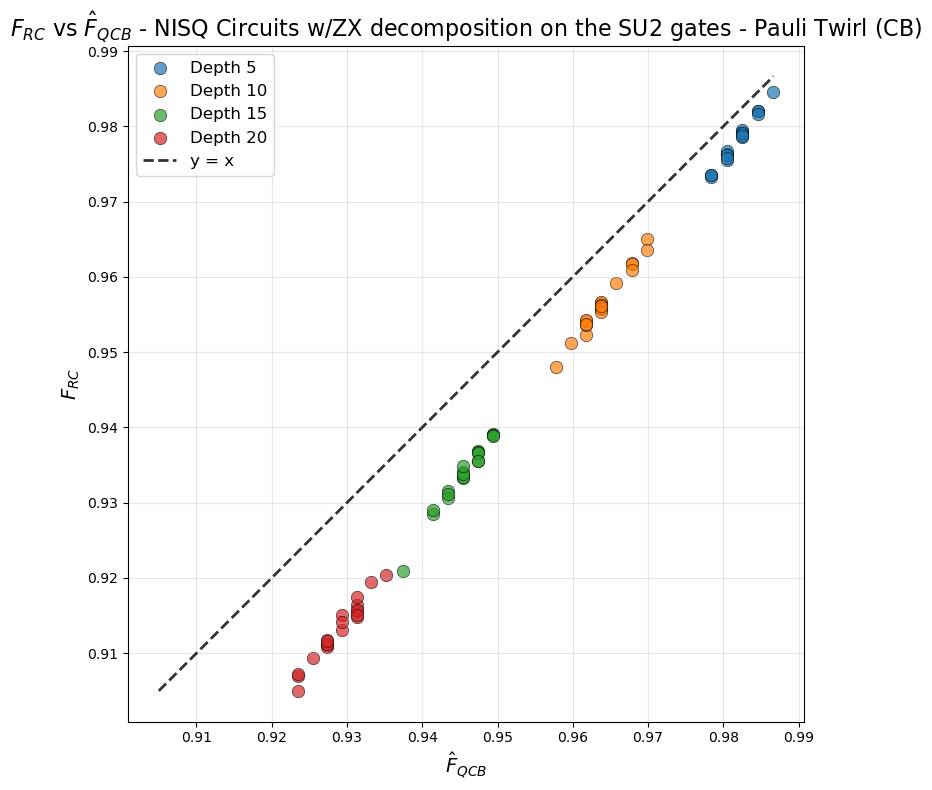

In [85]:
# Create scatter plot: F_RC (y-axis) vs F_CB (x-axis) with depth as legend
fig, ax = plt.subplots(figsize=(10, 8))

# Different colors for each depth
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
depth_color_map = {depth: colors[i] for i, depth in enumerate(depths)}

# Plot scatter points for each depth
for depth in depths:
    depth_data = df[df['Number of CNOT gate cycles'] == depth]
    color = depth_color_map[depth]
    
    ax.scatter(depth_data[r'\hat{F}_{QCB}'], depth_data['F_{RC}'], 
               color=color, label=f'Depth {depth}', 
               alpha=0.7, s=80, edgecolors='black', linewidths=0.5)

# Plot y = x line for reference
min_val = min(df[r'\hat{F}_{QCB}'].min(), df['F_{RC}'].min())
max_val = max(df[r'\hat{F}_{QCB}'].max(), df['F_{RC}'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2, label='y = x')

ax.set_xlabel(r'$\hat{F}_{QCB}$', fontsize=14)
ax.set_ylabel('$F_{RC}$', fontsize=14)
ax.set_title('$F_{RC}$ vs $\\hat{F}_{QCB}$ - NISQ Circuits w/ZX decomposition on the SU2 gates - Pauli Twirl (CB)' , fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Make axes equal for better visualization
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [115]:
circ = tq.Circuit([{0:Gate.x, 1:Gate.random(2), 2: Gate.x, 3: Gate.random(2)}, {(0,1): Gate.cx, (2,3): Gate.cx}, {0:Gate.random(2), 1: Gate.random(2), 2: Gate.z, 3:Gate.i}])
circ.draw()

DisplayWrapper(<svg xmlns="http://w...)

In [116]:
circs = tq.randomly_compile(circ, n_compilations=5)

In [117]:
circs[0].draw()

DisplayWrapper(<svg xmlns="http://w...)